In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
/content/drive/MyDrive/cvprojectdataset.zip

In [3]:
!pip install nibabel scikit-image opencv-python pandas matplotlib -q

In [4]:
import os
import glob
import cv2
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage.util import random_noise
from google.colab import drive

In [7]:
import glob
import os

zip_files = glob.glob("/content/drive/MyDrive/cvprojectdataset.zip", recursive=True)

print("zip files found:", len(zip_files))

for file in zip_files:
    print(file)

zip files found: 1
/content/drive/MyDrive/cvprojectdataset.zip


In [8]:
zip_path = "/content/drive/MyDrive/cvprojectdataset.zip"

extract_path = "/content/brats_ped_dataset"

os.makedirs(extract_path, exist_ok=True)

!unzip -q "$zip_path" -d "$extract_path"

print("dataset extracted successfully")

dataset extracted successfully


In [9]:
#all patient folder
patient_folders = sorted(glob.glob("/content/brats_ped_dataset/**/BraTS-PED-*", recursive=True))

patient_folders = [folder for folder in patient_folders if os.path.isdir(folder)]

print("total patient folders found:", len(patient_folders))

for folder in patient_folders[:10]:
    print(folder)

total patient folders found: 25
/content/brats_ped_dataset/Dataset/BraTS-PED-00128-000
/content/brats_ped_dataset/Dataset/BraTS-PED-00129-000
/content/brats_ped_dataset/Dataset/BraTS-PED-00130-000
/content/brats_ped_dataset/Dataset/BraTS-PED-00131-000
/content/brats_ped_dataset/Dataset/BraTS-PED-00132-000
/content/brats_ped_dataset/Dataset/BraTS-PED-00133-000
/content/brats_ped_dataset/Dataset/BraTS-PED-00134-000
/content/brats_ped_dataset/Dataset/BraTS-PED-00135-000
/content/brats_ped_dataset/Dataset/BraTS-PED-00136-000
/content/brats_ped_dataset/Dataset/BraTS-PED-00137-000


In [10]:
#create output folders for assignment 1

output_path = "/content/assignment_1_outputs"

before_after_path = os.path.join(output_path, "before_after_dataset")
metrics_path = os.path.join(output_path, "metrics")
anti_aliasing_path = os.path.join(output_path, "anti_aliasing_examples")

os.makedirs(before_after_path, exist_ok=True)
os.makedirs(metrics_path, exist_ok=True)
os.makedirs(anti_aliasing_path, exist_ok=True)

print("output folder created:")
print(output_path)

output folder created:
/content/assignment_1_outputs


In [11]:
#check if patient folders are available

print("total patient folders found:", len(patient_folders))

for folder in patient_folders[:5]:
    print(os.path.basename(folder))

total patient folders found: 25
BraTS-PED-00128-000
BraTS-PED-00129-000
BraTS-PED-00130-000
BraTS-PED-00131-000
BraTS-PED-00132-000


In [12]:
#check mri files inside one patient folder

sample_folder = patient_folders[0]

sample_files = sorted(glob.glob(os.path.join(sample_folder, "*.nii.gz")))

print("sample folder:", os.path.basename(sample_folder))
print("total nii.gz files found:", len(sample_files))

for file in sample_files:
    print(os.path.basename(file))

sample folder: BraTS-PED-00128-000
total nii.gz files found: 5
BraTS-PED-00128-000-seg.nii.gz
BraTS-PED-00128-000-t1c.nii.gz
BraTS-PED-00128-000-t1n.nii.gz
BraTS-PED-00128-000-t2f.nii.gz
BraTS-PED-00128-000-t2w.nii.gz


In [14]:
#define helper functions for loading and normalizing mri data

def load_mri(file_path):
  img = nib.load(file_path)
  data = img.get_fdata()
  dtype = img.get_data_dtype()
  return data, dtype


def normalize_to_uint8(slice_2d):
  slice_2d = slice_2d.astype(np.float32)

  min_value = np.min(slice_2d)
  max_value = np.max(slice_2d)

  if max_value - min_value == 0:
    return np.zeros_like(slice_2d, dtype=np.uint8)

  normalized = (slice_2d - min_value) / (max_value - min_value)
  uint8_img = (normalized * 255).astype(np.uint8)

  return uint8_img

In [15]:
#select the best slice from a 3d mri volume

def get_best_slice(volume):
  non_zero_counts = []

  for i in range(volume.shape[2]):
    slice_2d = volume[:, :, i]
    non_zero_counts.append(np.count_nonzero(slice_2d))

  best_index = int(np.argmax(non_zero_counts))
  best_slice = volume[:, :, best_index]

  return best_slice, best_index

file name: BraTS-PED-00128-000-t2w.nii.gz
volume shape: (240, 240, 155)
original data type: float64
selected slice index: 140
minimum intensity: 0.0
maximum intensity: 19475.4140625


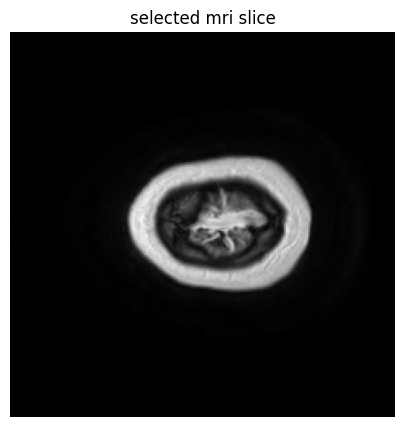

In [23]:
#open one mri file and display its selected slice

sample_file = sample_files[4]

volume, dtype = load_mri(sample_file)

best_slice, best_index = get_best_slice(volume)
best_slice_uint8 = normalize_to_uint8(best_slice)

print("file name:", os.path.basename(sample_file))
print("volume shape:", volume.shape)
print("original data type:", dtype)
print("selected slice index:", best_index)
print("minimum intensity:", np.min(volume))
print("maximum intensity:", np.max(volume))

plt.figure(figsize=(5, 5))
plt.imshow(best_slice_uint8, cmap="gray")
plt.title("selected mri slice")
plt.axis("off")
plt.show()

In [17]:
# check bit-depth and intensity range for all mri files

bit_depth_records = []

for patient_folder in patient_folders:
    patient_id = os.path.basename(patient_folder)
    nii_files = sorted(glob.glob(os.path.join(patient_folder, "*.nii.gz")))

    for file_path in nii_files:
        try:
            volume, dtype = load_mri(file_path)

            bit_depth_records.append({
                "patient_id": patient_id,
                "file_name": os.path.basename(file_path),
                "original_dtype": str(dtype),
                "shape": str(volume.shape),
                "min_intensity": float(np.min(volume)),
                "max_intensity": float(np.max(volume)),
                "mean_intensity": float(np.mean(volume)),
                "note": "converted to 8-bit only for visualization and filtering"
            })

        except Exception as e:
            print("error reading:", os.path.basename(file_path))
            print(e)

bit_depth_df = pd.DataFrame(bit_depth_records)

bit_depth_csv = os.path.join(output_path, "bit_depth_summary.csv")
bit_depth_df.to_csv(bit_depth_csv, index=False)

print("bit-depth summary saved at:")
print(bit_depth_csv)

bit_depth_df.head()

error reading: BraTS-PED-00130-000-t2f.nii.gz
Error -3 while decompressing data: too many length or distance symbols
bit-depth summary saved at:
/content/assignment_1_outputs/bit_depth_summary.csv


,patient_id,file_name,original_dtype,shape,min_intensity,max_intensity,mean_intensity,note
0,BraTS-PED-00128-000,BraTS-PED-00128-000-seg.nii.gz,uint16,"(240, 240, 155)",0.0,2.000000,0.004214,converted to 8-bit only for visualization and ...
1,BraTS-PED-00128-000,BraTS-PED-00128-000-t1c.nii.gz,float64,"(240, 240, 155)",0.0,19479.394531,1633.800096,converted to 8-bit only for visualization and ...
2,BraTS-PED-00128-000,BraTS-PED-00128-000-t1n.nii.gz,float64,"(240, 240, 155)",0.0,4787.407715,423.764620,converted to 8-bit only for visualization and ...
3,BraTS-PED-00128-000,BraTS-PED-00128-000-t2f.nii.gz,float64,"(240, 240, 155)",0.0,4706.450195,436.784869,converted to 8-bit only for visualization and ...
4,BraTS-PED-00128-000,BraTS-PED-00128-000-t2w.nii.gz,float64,"(240, 240, 155)",0.0,19475.414062,1633.800174,converted to 8-bit only for visualization and ...


filtering

In [19]:
def apply_mean_filter(img):
    return cv2.blur(img, (5, 5))


def apply_gaussian_filter(img):
    return cv2.GaussianBlur(img, (5, 5), 1)


def apply_median_filter(img):
    return cv2.medianBlur(img, 5)

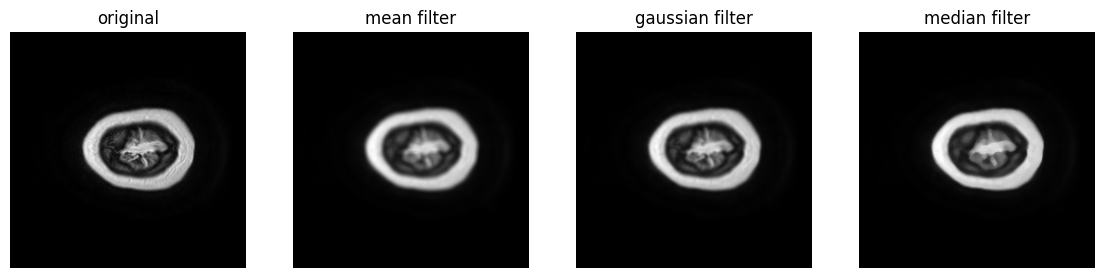

In [20]:
# apply filters on one sample mri slice

mean_img = apply_mean_filter(best_slice_uint8)
gaussian_img = apply_gaussian_filter(best_slice_uint8)
median_img = apply_median_filter(best_slice_uint8)

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(best_slice_uint8, cmap="gray")
plt.title("original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(mean_img, cmap="gray")
plt.title("mean filter")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(gaussian_img, cmap="gray")
plt.title("gaussian filter")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(median_img, cmap="gray")
plt.title("median filter")
plt.axis("off")

plt.show()

psnr and ssim

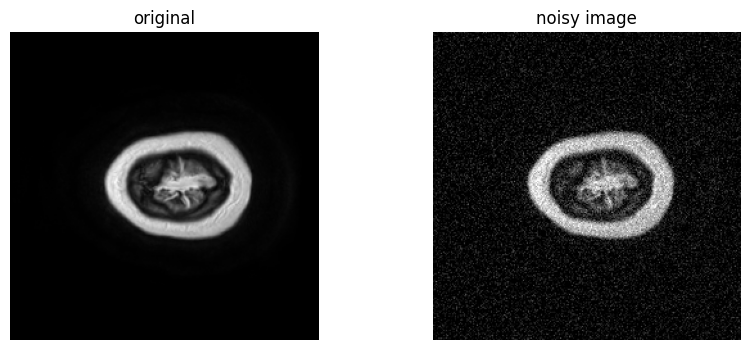

In [24]:
# add artificial gaussian noise to the mri slice

def add_gaussian_noise(img):
    img_float = img / 255.0
    noisy = random_noise(img_float, mode="gaussian", var=0.01)
    noisy = (noisy * 255).astype(np.uint8)
    return noisy


noisy_img = add_gaussian_noise(best_slice_uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(best_slice_uint8, cmap="gray")
plt.title("original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy_img, cmap="gray")
plt.title("noisy image")
plt.axis("off")

plt.show()

In [25]:
# calculate psnr and ssim values

def calculate_metrics(original_img, restored_img):
    psnr_value = peak_signal_noise_ratio(original_img, restored_img, data_range=255)
    ssim_value = structural_similarity(original_img, restored_img, data_range=255)
    return psnr_value, ssim_value


mean_restored = apply_mean_filter(noisy_img)
gaussian_restored = apply_gaussian_filter(noisy_img)
median_restored = apply_median_filter(noisy_img)

mean_psnr, mean_ssim = calculate_metrics(best_slice_uint8, mean_restored)
gaussian_psnr, gaussian_ssim = calculate_metrics(best_slice_uint8, gaussian_restored)
median_psnr, median_ssim = calculate_metrics(best_slice_uint8, median_restored)

sample_metrics = pd.DataFrame({
    "filter": ["mean", "gaussian", "median"],
    "psnr": [mean_psnr, gaussian_psnr, median_psnr],
    "ssim": [mean_ssim, gaussian_ssim, median_ssim]
})

sample_metrics

,filter,psnr,ssim
0,mean,27.337181,0.307279
1,gaussian,27.596011,0.297015
2,median,31.652206,0.627036


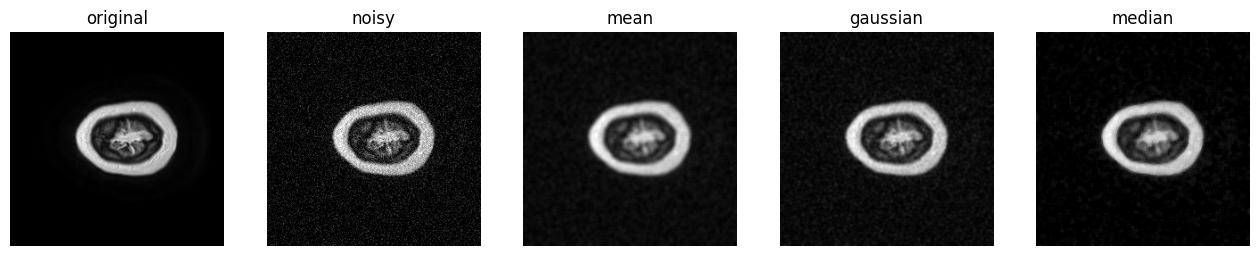

In [26]:
# show noisy image and restored images

plt.figure(figsize=(16, 4))

plt.subplot(1, 5, 1)
plt.imshow(best_slice_uint8, cmap="gray")
plt.title("original")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(noisy_img, cmap="gray")
plt.title("noisy")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(mean_restored, cmap="gray")
plt.title("mean")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(gaussian_restored, cmap="gray")
plt.title("gaussian")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(median_restored, cmap="gray")
plt.title("median")
plt.axis("off")

plt.show()

anti-aliasing before downsampling

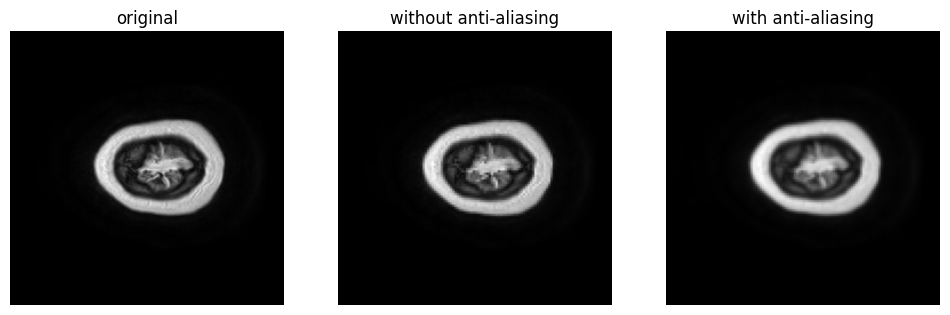

In [27]:
# downsample image with and without gaussian anti-aliasing

def downsample_without_antialiasing(img):
    return cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)


def downsample_with_antialiasing(img):
    blurred = cv2.GaussianBlur(img, (5, 5), 1)
    return cv2.resize(blurred, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)


down_no_aa = downsample_without_antialiasing(best_slice_uint8)
down_with_aa = downsample_with_antialiasing(best_slice_uint8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(best_slice_uint8, cmap="gray")
plt.title("original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(down_no_aa, cmap="gray")
plt.title("without anti-aliasing")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(down_with_aa, cmap="gray")
plt.title("with anti-aliasing")
plt.axis("off")

plt.show()

In [28]:
# save anti-aliasing example images

cv2.imwrite(os.path.join(anti_aliasing_path, "original.png"), best_slice_uint8)
cv2.imwrite(os.path.join(anti_aliasing_path, "downsample_without_antialiasing.png"), down_no_aa)
cv2.imwrite(os.path.join(anti_aliasing_path, "downsample_with_gaussian_antialiasing.png"), down_with_aa)

print("anti-aliasing examples saved at:")
print(anti_aliasing_path)

anti-aliasing examples saved at:
/content/assignment_1_outputs/anti_aliasing_examples


batch processing for all patient folders

In [29]:
# batch process all patient folders and save before-after results

all_metrics = []

max_patients = None

selected_folders = patient_folders

if max_patients is not None:
    selected_folders = patient_folders[:max_patients]

for patient_folder in selected_folders:
    patient_id = os.path.basename(patient_folder)
    print("processing:", patient_id)

    patient_output = os.path.join(before_after_path, patient_id)
    os.makedirs(patient_output, exist_ok=True)

    nii_files = sorted(glob.glob(os.path.join(patient_folder, "*.nii.gz")))

    for file_path in nii_files:
        file_name = os.path.basename(file_path)

        if "seg" in file_name.lower():
            continue

        try:
            volume, dtype = load_mri(file_path)
            selected_slice, slice_index = get_best_slice(volume)
            original_img = normalize_to_uint8(selected_slice)

            noisy_img = add_gaussian_noise(original_img)

            mean_img = apply_mean_filter(noisy_img)
            gaussian_img = apply_gaussian_filter(noisy_img)
            median_img = apply_median_filter(noisy_img)

            mean_psnr, mean_ssim = calculate_metrics(original_img, mean_img)
            gaussian_psnr, gaussian_ssim = calculate_metrics(original_img, gaussian_img)
            median_psnr, median_ssim = calculate_metrics(original_img, median_img)

            base_name = file_name.replace(".nii.gz", "")

            cv2.imwrite(os.path.join(patient_output, base_name + "_original.png"), original_img)
            cv2.imwrite(os.path.join(patient_output, base_name + "_noisy.png"), noisy_img)
            cv2.imwrite(os.path.join(patient_output, base_name + "_mean.png"), mean_img)
            cv2.imwrite(os.path.join(patient_output, base_name + "_gaussian.png"), gaussian_img)
            cv2.imwrite(os.path.join(patient_output, base_name + "_median.png"), median_img)

            all_metrics.append({
                "patient_id": patient_id,
                "file_name": file_name,
                "modality": base_name.split("-")[-1],
                "slice_index": slice_index,
                "original_dtype": str(dtype),
                "mean_psnr": mean_psnr,
                "mean_ssim": mean_ssim,
                "gaussian_psnr": gaussian_psnr,
                "gaussian_ssim": gaussian_ssim,
                "median_psnr": median_psnr,
                "median_ssim": median_ssim
            })

        except Exception as e:
            print("error in file:", file_name)
            print(e)

metrics_df = pd.DataFrame(all_metrics)

metrics_csv = os.path.join(metrics_path, "filter_metrics.csv")
metrics_df.to_csv(metrics_csv, index=False)

print("batch processing completed")
print("metrics saved at:")
print(metrics_csv)

metrics_df.head()

processing: BraTS-PED-00128-000
processing: BraTS-PED-00129-000
processing: BraTS-PED-00130-000
error in file: BraTS-PED-00130-000-t2f.nii.gz
Error -3 while decompressing data: too many length or distance symbols
processing: BraTS-PED-00131-000
processing: BraTS-PED-00132-000
processing: BraTS-PED-00133-000
processing: BraTS-PED-00134-000
processing: BraTS-PED-00135-000
processing: BraTS-PED-00136-000
processing: BraTS-PED-00137-000
processing: BraTS-PED-00138-000
processing: BraTS-PED-00139-000
processing: BraTS-PED-00140-000
processing: BraTS-PED-00141-000
processing: BraTS-PED-00142-000
processing: BraTS-PED-00143-000
processing: BraTS-PED-00144-000
processing: BraTS-PED-00145-000
processing: BraTS-PED-00146-000
processing: BraTS-PED-00147-000
processing: BraTS-PED-00148-000
processing: BraTS-PED-00149-000
processing: BraTS-PED-00150-000
processing: BraTS-PED-00151-000
processing: BraTS-PED-00152-000
batch processing completed
metrics saved at:
/content/assignment_1_outputs/metrics/

,patient_id,file_name,modality,slice_index,original_dtype,mean_psnr,mean_ssim,gaussian_psnr,gaussian_ssim,median_psnr,median_ssim
0,BraTS-PED-00128-000,BraTS-PED-00128-000-t1c.nii.gz,t1c,140,float64,27.439613,0.308327,27.709723,0.299274,31.795886,0.636869
1,BraTS-PED-00128-000,BraTS-PED-00128-000-t1n.nii.gz,t1n,152,float64,25.660425,0.301886,26.230676,0.375005,26.941398,0.452032
2,BraTS-PED-00128-000,BraTS-PED-00128-000-t2f.nii.gz,t2f,152,float64,26.214196,0.318889,26.620806,0.381326,27.348129,0.463210
3,BraTS-PED-00128-000,BraTS-PED-00128-000-t2w.nii.gz,t2w,140,float64,27.527093,0.310487,27.806401,0.301184,31.858499,0.662712
4,BraTS-PED-00129-000,BraTS-PED-00129-000-t1c.nii.gz,t1c,79,float64,26.164810,0.398383,27.391569,0.387083,28.918666,0.653352


In [30]:
# calculate average psnr and ssim for each filter

average_results = pd.DataFrame({
    "filter": ["mean", "gaussian", "median"],
    "average_psnr": [
        metrics_df["mean_psnr"].mean(),
        metrics_df["gaussian_psnr"].mean(),
        metrics_df["median_psnr"].mean()
    ],
    "average_ssim": [
        metrics_df["mean_ssim"].mean(),
        metrics_df["gaussian_ssim"].mean(),
        metrics_df["median_ssim"].mean()
    ]
})

average_csv = os.path.join(metrics_path, "average_filter_results.csv")
average_results.to_csv(average_csv, index=False)

average_results

,filter,average_psnr,average_ssim
0,mean,26.792550,0.441840
1,gaussian,27.476739,0.439083
2,median,29.123338,0.643848


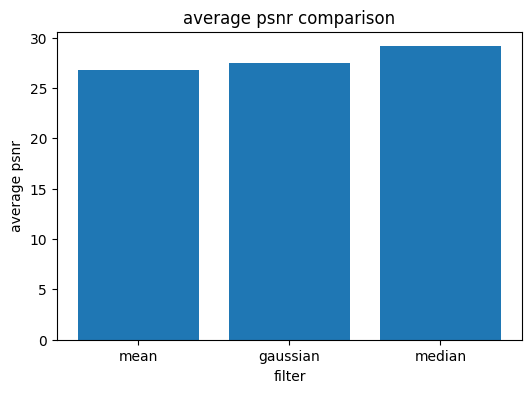

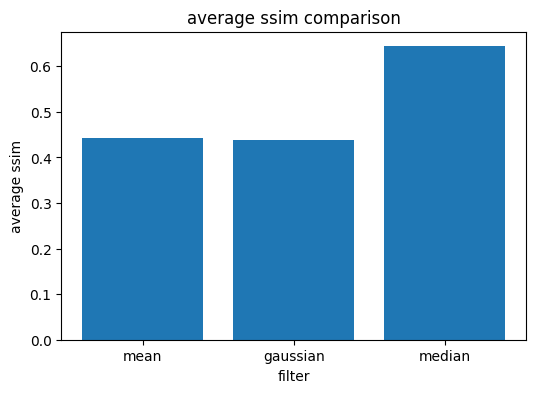

In [31]:
# plot average psnr and ssim comparison

plt.figure(figsize=(6, 4))
plt.bar(average_results["filter"], average_results["average_psnr"])
plt.title("average psnr comparison")
plt.xlabel("filter")
plt.ylabel("average psnr")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(average_results["filter"], average_results["average_ssim"])
plt.title("average ssim comparison")
plt.xlabel("filter")
plt.ylabel("average ssim")
plt.show()

In [32]:
# check saved assignment 1 output folders

print("main output folder:")
print(output_path)

print("\nfolders inside output path:")
for item in os.listdir(output_path):
    print("-", item)

print("\nmetrics files:")
for item in os.listdir(metrics_path):
    print("-", item)

main output folder:
/content/assignment_1_outputs

folders inside output path:
- before_after_dataset
- anti_aliasing_examples
- bit_depth_summary.csv
- metrics

metrics files:
- filter_metrics.csv
- average_filter_results.csv


In [33]:
# create zip file for downloading assignment 1 outputs

!zip -r /content/assignment_1_outputs.zip /content/assignment_1_outputs > /dev/null

print("zip file created:")
print("/content/assignment_1_outputs.zip")

zip file created:
/content/assignment_1_outputs.zip


## Short Report Summary

In this assignment, the BraTS-PED brain tumor MRI dataset was used for radiometric preprocessing and noise mitigation. The dataset contains 3D MRI files in `.nii.gz` format, so one clear 2D slice was selected from each MRI volume for processing.

First, the dataset was loaded in batch form and the radiometric details such as data type, shape, and intensity range were checked. The selected slices were then converted into 8-bit grayscale images for visualization. Gaussian noise was added to test the performance of noise removal filters.

Mean, Gaussian, and median filters were applied to reduce noise. The results were evaluated using PSNR and SSIM values. Higher PSNR and SSIM values showed better image restoration. Anti-aliasing was also tested by downsampling the image with and without Gaussian pre-filtering. The Gaussian pre-filter helped reduce aliasing effects and produced a smoother resized image.

# **ASSIGNMENT NO 2**

In [34]:
#create output folders for assignment 2

assignment_2_path = "/content/assignment_2_outputs"

mask_path = os.path.join(assignment_2_path, "masks")
morphology_path = os.path.join(assignment_2_path, "morphological_cleaning")
chain_code_path = os.path.join(assignment_2_path, "chain_code_tables")
hull_path = os.path.join(assignment_2_path, "convex_hull_overlays")

os.makedirs(mask_path, exist_ok=True)
os.makedirs(morphology_path, exist_ok=True)
os.makedirs(chain_code_path, exist_ok=True)
os.makedirs(hull_path, exist_ok=True)

print("assignment 2 folders created:")
print(assignment_2_path)

assignment 2 folders created:
/content/assignment_2_outputs


In [35]:
#check patient folders before starting assignment 2

print("total patient folders found:", len(patient_folders))

for folder in patient_folders[:5]:
    print(os.path.basename(folder))

total patient folders found: 25
BraTS-PED-00128-000
BraTS-PED-00129-000
BraTS-PED-00130-000
BraTS-PED-00131-000
BraTS-PED-00132-000


In [36]:
# define helper functions to load mri and normalize slices

def load_mri(file_path):
    img = nib.load(file_path)
    data = img.get_fdata()
    return data


def normalize_to_uint8(slice_2d):
    slice_2d = slice_2d.astype(np.float32)

    min_value = np.min(slice_2d)
    max_value = np.max(slice_2d)

    if max_value - min_value == 0:
        return np.zeros_like(slice_2d, dtype=np.uint8)

    normalized = (slice_2d - min_value) / (max_value - min_value)
    uint8_img = (normalized * 255).astype(np.uint8)

    return uint8_img

In [37]:
# find mri modality file and segmentation file from each patient folder

def find_file(patient_folder, keyword):
    files = sorted(glob.glob(os.path.join(patient_folder, "*.nii.gz")))

    for file in files:
        name = os.path.basename(file).lower()
        if name.endswith("-" + keyword + ".nii.gz"):
            return file

    return None


def get_best_modality_file(patient_folder):
    preferred_modalities = ["t2f", "t2w", "t1c", "t1n"]

    for modality in preferred_modalities:
        file_path = find_file(patient_folder, modality)
        if file_path is not None:
            return file_path, modality

    return None, None


def get_seg_file(patient_folder):
    return find_file(patient_folder, "seg")

In [38]:
# select the slice where tumor area is maximum

def get_tumor_slice_index(seg_volume):
    slice_counts = []

    for i in range(seg_volume.shape[2]):
        seg_slice = seg_volume[:, :, i]
        tumor_pixels = np.count_nonzero(seg_slice)
        slice_counts.append(tumor_pixels)

    best_index = int(np.argmax(slice_counts))
    return best_index


def get_best_brain_slice_index(volume):
    slice_counts = []

    for i in range(volume.shape[2]):
        img_slice = volume[:, :, i]
        non_zero_pixels = np.count_nonzero(img_slice)
        slice_counts.append(non_zero_pixels)

    best_index = int(np.argmax(slice_counts))
    return best_index

segmentation and masking

In [39]:
# create binary mask using sobel edge detection

def create_sobel_mask(img_uint8, reference_mask=None):
    blurred = cv2.GaussianBlur(img_uint8, (5, 5), 1)

    sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

    gradient = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
    gradient = normalize_to_uint8(gradient)

    _, edge_mask = cv2.threshold(
        gradient, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    if reference_mask is not None:
        kernel = np.ones((9, 9), np.uint8)
        region = cv2.dilate(reference_mask, kernel, iterations=2)
        edge_mask = cv2.bitwise_and(edge_mask, edge_mask, mask=region)

    return edge_mask

In [40]:
# create binary edge mask using canny edge detection

def create_canny_mask(img_uint8, reference_mask=None):
    blurred = cv2.GaussianBlur(img_uint8, (5, 5), 1)

    edge_mask = cv2.Canny(blurred, 40, 120)

    if reference_mask is not None:
        kernel = np.ones((9, 9), np.uint8)
        region = cv2.dilate(reference_mask, kernel, iterations=2)
        edge_mask = cv2.bitwise_and(edge_mask, edge_mask, mask=region)

    return edge_mask

In [41]:
# fill object area from edge mask

def fill_object_from_edges(edge_mask):
    closed = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    filled_mask = np.zeros_like(edge_mask)

    if len(contours) == 0:
        return filled_mask

    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    for contour in contours[:3]:
        area = cv2.contourArea(contour)
        if area > 20:
            cv2.drawContours(filled_mask, [contour], -1, 255, thickness=-1)

    return filled_mask

In [42]:
# fill object area from edge mask

def fill_object_from_edges(edge_mask):
    closed = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    filled_mask = np.zeros_like(edge_mask)

    if len(contours) == 0:
        return filled_mask

    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    for contour in contours[:3]:
        area = cv2.contourArea(contour)
        if area > 20:
            cv2.drawContours(filled_mask, [contour], -1, 255, thickness=-1)

    return filled_mask

morphological cleaning

In [43]:
# apply morphological cleaning operations

def apply_morphological_cleaning(binary_mask):
    kernel = np.ones((5, 5), np.uint8)

    erosion = cv2.erode(binary_mask, kernel, iterations=1)
    dilation = cv2.dilate(binary_mask, kernel, iterations=1)
    opening = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    return erosion, dilation, opening, closing

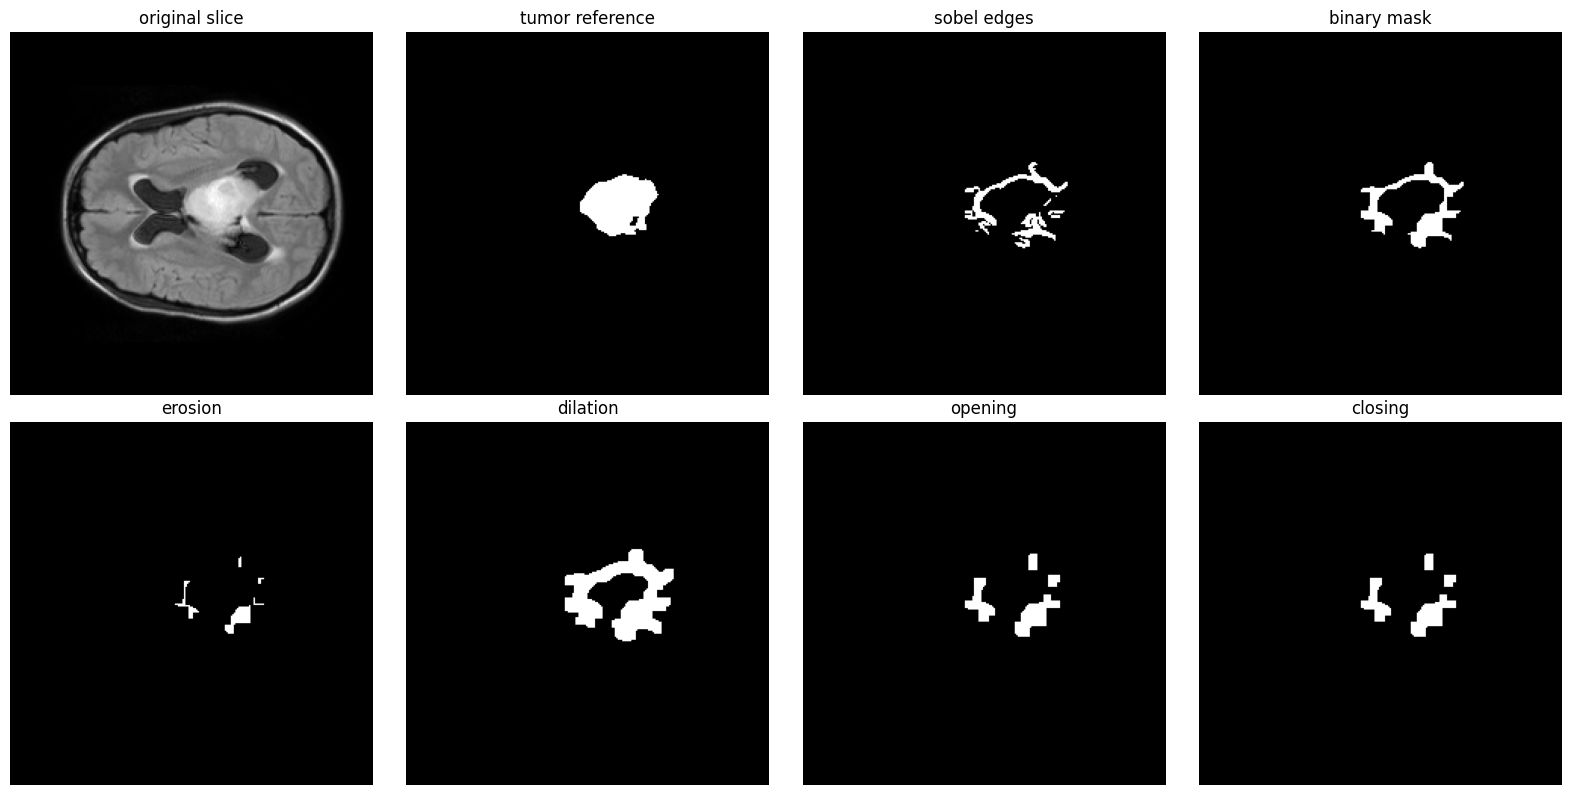

In [45]:
# test assignment 2 on one patient folder

sample_folder = patient_folders[1]

modality_file, modality_name = get_best_modality_file(sample_folder)
seg_file = get_seg_file(sample_folder)

mri_volume = load_mri(modality_file)
seg_volume = load_mri(seg_file)

slice_index = get_tumor_slice_index(seg_volume)

mri_slice = mri_volume[:, :, slice_index]
seg_slice = seg_volume[:, :, slice_index]

img_uint8 = normalize_to_uint8(mri_slice)
reference_mask = (seg_slice > 0).astype(np.uint8) * 255

sobel_edges = create_sobel_mask(img_uint8, reference_mask)
canny_edges = create_canny_mask(img_uint8, reference_mask)

binary_mask = fill_object_from_edges(sobel_edges)

if np.count_nonzero(binary_mask) == 0:
    binary_mask = reference_mask.copy()

erosion, dilation, opening, closing = apply_morphological_cleaning(binary_mask)

plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
plt.imshow(img_uint8, cmap="gray")
plt.title("original slice")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(reference_mask, cmap="gray")
plt.title("tumor reference")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(sobel_edges, cmap="gray")
plt.title("sobel edges")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(binary_mask, cmap="gray")
plt.title("binary mask")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(erosion, cmap="gray")
plt.title("erosion")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(dilation, cmap="gray")
plt.title("dilation")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(opening, cmap="gray")
plt.title("opening")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(closing, cmap="gray")
plt.title("closing")
plt.axis("off")

plt.tight_layout()
plt.show()

boundary representation

In [46]:
# find main contour from cleaned binary mask

def get_main_contour(cleaned_mask):
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if len(contours) == 0:
        return None

    main_contour = max(contours, key=cv2.contourArea)
    return main_contour

In [47]:
# generate 8-directional chain code from contour points

def generate_chain_code(contour):
    points = contour[:, 0, :]

    direction_map = {
        (1, 0): 0,
        (1, -1): 1,
        (0, -1): 2,
        (-1, -1): 3,
        (-1, 0): 4,
        (-1, 1): 5,
        (0, 1): 6,
        (1, 1): 7
    }

    chain_codes = []
    table_rows = []

    for i in range(len(points)):
        current_point = points[i]
        next_point = points[(i + 1) % len(points)]

        dx = int(np.sign(next_point[0] - current_point[0]))
        dy = int(np.sign(next_point[1] - current_point[1]))

        code = direction_map.get((dx, dy), -1)

        if code != -1:
            chain_codes.append(code)

            table_rows.append({
                "step": i,
                "x": int(current_point[0]),
                "y": int(current_point[1]),
                "next_x": int(next_point[0]),
                "next_y": int(next_point[1]),
                "chain_code": code
            })

    return chain_codes, pd.DataFrame(table_rows)

In [48]:
# calculate first difference and shape number

def calculate_first_difference(chain_codes):
    first_difference = []

    for i in range(len(chain_codes)):
        current_code = chain_codes[i]
        next_code = chain_codes[(i + 1) % len(chain_codes)]
        diff = (next_code - current_code) % 8
        first_difference.append(diff)

    return first_difference


def get_shape_number(first_difference):
    if len(first_difference) == 0:
        return []

    rotations = []

    for i in range(len(first_difference)):
        rotated = first_difference[i:] + first_difference[:i]
        rotations.append(rotated)

    shape_number = min(rotations)
    return shape_number

computational geometry

In [49]:
# implement graham scan algorithm for convex hull

def cross_product(o, a, b):
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def distance_squared(a, b):
    return (a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2


def graham_scan(points):
    points = list(set(points))

    if len(points) <= 1:
        return points

    start = min(points, key=lambda p: (p[1], p[0]))

    sorted_points = sorted(
        points,
        key=lambda p: (
            np.arctan2(p[1] - start[1], p[0] - start[0]),
            distance_squared(start, p)
        )
    )

    hull = []

    for point in sorted_points:
        while len(hull) >= 2 and cross_product(hull[-2], hull[-1], point) <= 0:
            hull.pop()
        hull.append(point)

    return hull

In [50]:
# draw convex hull overlay on original image

def draw_hull_overlay(img_uint8, contour, hull_points):
    overlay = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)

    cv2.drawContours(overlay, [contour], -1, (0, 0, 255), 1)

    if len(hull_points) >= 3:
        hull_array = np.array(hull_points, dtype=np.int32).reshape((-1, 1, 2))
        cv2.polylines(overlay, [hull_array], isClosed=True, color=(0, 255, 0), thickness=2)

    return overlay

chain code length: 98
first 30 chain codes: [6, 6, 6, 6, 5, 4, 4, 5, 4, 4, 4, 4, 4, 4, 5, 5, 6, 5, 5, 5, 6, 6, 6, 6, 6, 5, 4, 4, 4, 6]
first 30 first differences: [0, 0, 0, 7, 7, 0, 1, 7, 0, 0, 0, 0, 0, 1, 0, 1, 7, 0, 0, 1, 0, 0, 0, 0, 7, 7, 0, 0, 2, 0]
first 30 shape number values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 7, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 7, 7]
convex hull points: 12


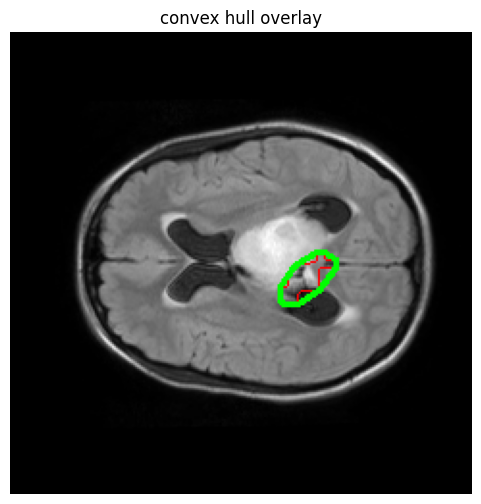

In [51]:
# test chain code and convex hull on one sample

cleaned_mask = closing.copy()

main_contour = get_main_contour(cleaned_mask)

if main_contour is not None:
    chain_codes, chain_table = generate_chain_code(main_contour)
    first_difference = calculate_first_difference(chain_codes)
    shape_number = get_shape_number(first_difference)

    chain_table["first_difference"] = first_difference[:len(chain_table)]

    contour_points = main_contour[:, 0, :]
    contour_points = [(int(p[0]), int(p[1])) for p in contour_points]

    hull_points = graham_scan(contour_points)
    hull_overlay = draw_hull_overlay(img_uint8, main_contour, hull_points)

    print("chain code length:", len(chain_codes))
    print("first 30 chain codes:", chain_codes[:30])
    print("first 30 first differences:", first_difference[:30])
    print("first 30 shape number values:", shape_number[:30])
    print("convex hull points:", len(hull_points))

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(hull_overlay, cv2.COLOR_BGR2RGB))
    plt.title("convex hull overlay")
    plt.axis("off")
    plt.show()

    chain_table.head()
else:
    print("no contour found")

batch process

In [52]:
summary_records = []

max_patients = None

selected_folders = patient_folders

if max_patients is not None:
    selected_folders = patient_folders[:max_patients]

for patient_folder in selected_folders:
    patient_id = os.path.basename(patient_folder)
    print("processing:", patient_id)

    modality_file, modality_name = get_best_modality_file(patient_folder)
    seg_file = get_seg_file(patient_folder)

    if modality_file is None or seg_file is None:
        print("missing modality or segmentation file:", patient_id)
        continue

    try:
        mri_volume = load_mri(modality_file)
        seg_volume = load_mri(seg_file)

        slice_index = get_tumor_slice_index(seg_volume)

        mri_slice = mri_volume[:, :, slice_index]
        seg_slice = seg_volume[:, :, slice_index]

        img_uint8 = normalize_to_uint8(mri_slice)
        reference_mask = (seg_slice > 0).astype(np.uint8) * 255

        sobel_edges = create_sobel_mask(img_uint8, reference_mask)
        canny_edges = create_canny_mask(img_uint8, reference_mask)

        binary_mask = fill_object_from_edges(sobel_edges)

        if np.count_nonzero(binary_mask) == 0:
            binary_mask = reference_mask.copy()

        erosion, dilation, opening, closing = apply_morphological_cleaning(binary_mask)
        cleaned_mask = closing.copy()

        main_contour = get_main_contour(cleaned_mask)

        if main_contour is None:
            print("no contour found:", patient_id)
            continue

        chain_codes, chain_table = generate_chain_code(main_contour)
        first_difference = calculate_first_difference(chain_codes)
        shape_number = get_shape_number(first_difference)

        chain_table["first_difference"] = first_difference[:len(chain_table)]

        contour_points = main_contour[:, 0, :]
        contour_points = [(int(p[0]), int(p[1])) for p in contour_points]

        hull_points = graham_scan(contour_points)
        hull_overlay = draw_hull_overlay(img_uint8, main_contour, hull_points)

        patient_mask_path = os.path.join(mask_path, patient_id)
        patient_morph_path = os.path.join(morphology_path, patient_id)

        os.makedirs(patient_mask_path, exist_ok=True)
        os.makedirs(patient_morph_path, exist_ok=True)

        cv2.imwrite(os.path.join(patient_mask_path, patient_id + "_original.png"), img_uint8)
        cv2.imwrite(os.path.join(patient_mask_path, patient_id + "_reference_mask.png"), reference_mask)
        cv2.imwrite(os.path.join(patient_mask_path, patient_id + "_sobel_edges.png"), sobel_edges)
        cv2.imwrite(os.path.join(patient_mask_path, patient_id + "_canny_edges.png"), canny_edges)
        cv2.imwrite(os.path.join(patient_mask_path, patient_id + "_binary_mask.png"), binary_mask)
        cv2.imwrite(os.path.join(patient_mask_path, patient_id + "_cleaned_mask.png"), cleaned_mask)

        cv2.imwrite(os.path.join(patient_morph_path, patient_id + "_erosion.png"), erosion)
        cv2.imwrite(os.path.join(patient_morph_path, patient_id + "_dilation.png"), dilation)
        cv2.imwrite(os.path.join(patient_morph_path, patient_id + "_opening.png"), opening)
        cv2.imwrite(os.path.join(patient_morph_path, patient_id + "_closing.png"), closing)

        chain_csv = os.path.join(chain_code_path, patient_id + "_chain_code_table.csv")
        chain_table.to_csv(chain_csv, index=False)

        hull_file = os.path.join(hull_path, patient_id + "_convex_hull_overlay.png")
        cv2.imwrite(hull_file, hull_overlay)

        summary_records.append({
            "patient_id": patient_id,
            "modality_used": modality_name,
            "slice_index": slice_index,
            "mask_area_pixels": int(np.count_nonzero(cleaned_mask)),
            "contour_points": int(len(contour_points)),
            "chain_code_length": int(len(chain_codes)),
            "convex_hull_points": int(len(hull_points)),
            "first_20_chain_codes": str(chain_codes[:20]),
            "first_20_first_differences": str(first_difference[:20]),
            "first_20_shape_number": str(shape_number[:20])
        })

    except Exception as e:
        print("error processing:", patient_id)
        print(e)

summary_df = pd.DataFrame(summary_records)

summary_csv = os.path.join(assignment_2_path, "assignment_2_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("assignment 2 batch processing completed")
print("summary saved at:")
print(summary_csv)

summary_df.head()

processing: BraTS-PED-00128-000
processing: BraTS-PED-00129-000
processing: BraTS-PED-00130-000
error processing: BraTS-PED-00130-000
Error -3 while decompressing data: too many length or distance symbols
processing: BraTS-PED-00131-000
processing: BraTS-PED-00132-000
processing: BraTS-PED-00133-000
processing: BraTS-PED-00134-000
processing: BraTS-PED-00135-000
processing: BraTS-PED-00136-000
processing: BraTS-PED-00137-000
processing: BraTS-PED-00138-000
processing: BraTS-PED-00139-000
processing: BraTS-PED-00140-000
processing: BraTS-PED-00141-000
processing: BraTS-PED-00142-000
processing: BraTS-PED-00143-000
processing: BraTS-PED-00144-000
processing: BraTS-PED-00145-000
processing: BraTS-PED-00146-000
processing: BraTS-PED-00147-000
processing: BraTS-PED-00148-000
processing: BraTS-PED-00149-000
processing: BraTS-PED-00150-000
processing: BraTS-PED-00151-000
processing: BraTS-PED-00152-000
assignment 2 batch processing completed
summary saved at:
/content/assignment_2_outputs/ass

,patient_id,modality_used,slice_index,mask_area_pixels,contour_points,chain_code_length,convex_hull_points,first_20_chain_codes,first_20_first_differences,first_20_shape_number
0,BraTS-PED-00128-000,t2f,123,1276,163,163,15,"[6, 6, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...","[0, 7, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 7, ..."
1,BraTS-PED-00129-000,t2f,77,777,98,98,12,"[6, 6, 6, 6, 5, 4, 4, 5, 4, 4, 4, 4, 4, 4, 5, ...","[0, 0, 0, 7, 7, 0, 1, 7, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 7, 0, 0, 0, ..."
2,BraTS-PED-00131-000,t2f,99,2665,234,234,18,"[5, 6, 6, 6, 6, 6, 5, 4, 4, 4, 4, 4, 4, 4, 3, ...","[1, 0, 0, 0, 0, 7, 7, 0, 0, 0, 0, 0, 0, 7, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,BraTS-PED-00132-000,t2f,109,504,127,127,8,"[6, 6, 6, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...","[0, 0, 7, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, ..."
4,BraTS-PED-00133-000,t2f,107,919,198,198,13,"[6, 6, 6, 6, 6, 7, 7, 6, 7, 6, 6, 7, 7, 6, 6, ...","[0, 0, 0, 0, 1, 0, 7, 1, 7, 0, 1, 0, 7, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


total convex hull overlays: 24


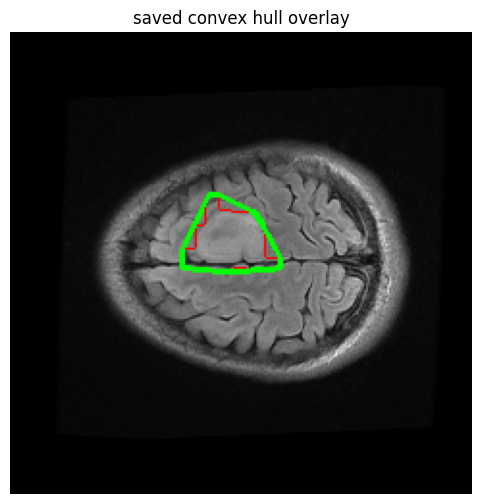

In [53]:
# view one saved convex hull overlay

hull_files = sorted(glob.glob(os.path.join(hull_path, "*.png")))

print("total convex hull overlays:", len(hull_files))

if len(hull_files) > 0:
    sample_hull = cv2.imread(hull_files[0])
    sample_hull = cv2.cvtColor(sample_hull, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(sample_hull)
    plt.title("saved convex hull overlay")
    plt.axis("off")
    plt.show()

In [54]:
# view one saved chain code table

chain_files = sorted(glob.glob(os.path.join(chain_code_path, "*.csv")))

print("total chain code tables:", len(chain_files))

if len(chain_files) > 0:
    sample_chain_table = pd.read_csv(chain_files[0])
    display(sample_chain_table.head(10))

total chain code tables: 24


,step,x,y,next_x,next_y,chain_code,first_difference
0,0,103,84,103,85,6,0
1,1,103,85,103,86,6,7
2,2,103,86,102,87,5,0
3,3,102,87,101,88,5,1
4,4,101,88,101,89,6,0
5,5,101,89,101,90,6,0
6,6,101,90,101,91,6,0
7,7,101,91,101,92,6,0
8,8,101,92,101,93,6,0
9,9,101,93,101,94,6,0


In [55]:
#create zip file for assignment 2 outputs

!zip -r /content/assignment_2_outputs.zip /content/assignment_2_outputs > /dev/null

print("zip file created:")
print("/content/assignment_2_outputs.zip")

zip file created:
/content/assignment_2_outputs.zip


# **ASSIGNMENT NO 3**

In [56]:
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [57]:
# create output folders for assignment 3

assignment_3_path = "/content/assignment_3_outputs"

feature_path = os.path.join(assignment_3_path, "feature_vectors")
report_path = os.path.join(assignment_3_path, "classification_report")
plot_path = os.path.join(assignment_3_path, "plots")

os.makedirs(feature_path, exist_ok=True)
os.makedirs(report_path, exist_ok=True)
os.makedirs(plot_path, exist_ok=True)

print("assignment 3 output folder created:")
print(assignment_3_path)

assignment 3 output folder created:
/content/assignment_3_outputs


In [58]:
# check patient folders before starting assignment 3

print("total patient folders found:", len(patient_folders))

for folder in patient_folders[:5]:
    print(os.path.basename(folder))

total patient folders found: 25
BraTS-PED-00128-000
BraTS-PED-00129-000
BraTS-PED-00130-000
BraTS-PED-00131-000
BraTS-PED-00132-000


In [59]:
# define helper functions for loading mri and normalizing slices

def load_mri(file_path):
    img = nib.load(file_path)
    data = img.get_fdata()
    return data


def normalize_to_uint8(slice_2d):
    slice_2d = slice_2d.astype(np.float32)

    min_value = np.min(slice_2d)
    max_value = np.max(slice_2d)

    if max_value - min_value == 0:
        return np.zeros_like(slice_2d, dtype=np.uint8)

    normalized = (slice_2d - min_value) / (max_value - min_value)
    uint8_img = (normalized * 255).astype(np.uint8)

    return uint8_img

In [60]:
# find modality and segmentation files from patient folder

def find_file(patient_folder, keyword):
    files = sorted(glob.glob(os.path.join(patient_folder, "*.nii.gz")))

    for file in files:
        name = os.path.basename(file).lower()
        if name.endswith("-" + keyword + ".nii.gz"):
            return file

    return None


def get_best_modality_file(patient_folder):
    preferred_modalities = ["t2f", "t2w", "t1c", "t1n"]

    for modality in preferred_modalities:
        file_path = find_file(patient_folder, modality)
        if file_path is not None:
            return file_path, modality

    return None, None


def get_seg_file(patient_folder):
    return find_file(patient_folder, "seg")

In [61]:
# select the slice where tumor region is maximum

def get_tumor_slice_index(seg_volume):
    slice_counts = []

    for i in range(seg_volume.shape[2]):
        seg_slice = seg_volume[:, :, i]
        tumor_pixels = np.count_nonzero(seg_slice)
        slice_counts.append(tumor_pixels)

    best_index = int(np.argmax(slice_counts))
    return best_index

glcm feature extraction

In [62]:
# calculate glcm texture features from masked region

def calculate_glcm_features(img_uint8, mask):
    masked_img = img_uint8.copy()
    masked_img[mask == 0] = 0

    coords = np.where(mask > 0)

    if len(coords[0]) == 0:
        return None

    y_min, y_max = np.min(coords[0]), np.max(coords[0])
    x_min, x_max = np.min(coords[1]), np.max(coords[1])

    roi = masked_img[y_min:y_max + 1, x_min:x_max + 1]
    roi_mask = mask[y_min:y_max + 1, x_min:x_max + 1]

    roi[roi_mask == 0] = 0

    roi = cv2.resize(roi, (64, 64))

    glcm = graycomatrix(
        roi,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    energy = graycoprops(glcm, "energy")[0, 0]
    contrast = graycoprops(glcm, "contrast")[0, 0]

    glcm_matrix = glcm[:, :, 0, 0]
    entropy = -np.sum(glcm_matrix * np.log2(glcm_matrix + 1e-10))

    return energy, entropy, contrast

geometric feature extraction

In [63]:
# calculate area, centroid, perimeter, and circularity

def calculate_geometric_features(mask):
    mask_uint8 = mask.astype(np.uint8)

    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    main_contour = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(main_contour)
    perimeter = cv2.arcLength(main_contour, True)

    moments = cv2.moments(main_contour)

    if moments["m00"] != 0:
        centroid_x = moments["m10"] / moments["m00"]
        centroid_y = moments["m01"] / moments["m00"]
    else:
        centroid_x = 0
        centroid_y = 0

    if perimeter != 0:
        circularity = (4 * np.pi * area) / (perimeter ** 2)
    else:
        circularity = 0

    return area, centroid_x, centroid_y, perimeter, circularity

create feature vector dataset

In [70]:
# extract texture and geometric features from multiple tumor slices

feature_records = []

max_patients = None
max_slices_per_patient = 8

selected_folders = patient_folders

if max_patients is not None:
    selected_folders = patient_folders[:max_patients]

for patient_folder in selected_folders:
    patient_id = os.path.basename(patient_folder)
    print("processing:", patient_id)

    modality_file, modality_name = get_best_modality_file(patient_folder)
    seg_file = get_seg_file(patient_folder)

    if modality_file is None or seg_file is None:
        print("missing modality or segmentation file:", patient_id)
        continue

    try:
        mri_volume = load_mri(modality_file)
        seg_volume = load_mri(seg_file)

        tumor_counts = []

        for i in range(seg_volume.shape[2]):
            tumor_counts.append(np.count_nonzero(seg_volume[:, :, i]))

        tumor_counts = np.array(tumor_counts)
        valid_slices = np.where(tumor_counts > 50)[0]

        if len(valid_slices) == 0:
            continue

        sorted_slices = valid_slices[np.argsort(tumor_counts[valid_slices])[::-1]]
        selected_slices = sorted_slices[:max_slices_per_patient]

        for slice_index in selected_slices:
            mri_slice = mri_volume[:, :, slice_index]
            seg_slice = seg_volume[:, :, slice_index]

            img_uint8 = normalize_to_uint8(mri_slice)

            unique_labels = np.unique(seg_slice)
            unique_labels = unique_labels[unique_labels != 0]

            for label_value in unique_labels:
                region_mask = (seg_slice == label_value).astype(np.uint8) * 255

                if np.count_nonzero(region_mask) < 30:
                    continue

                glcm_features = calculate_glcm_features(img_uint8, region_mask)
                geo_features = calculate_geometric_features(region_mask)

                if glcm_features is None or geo_features is None:
                    continue

                energy, entropy, contrast = glcm_features
                area, centroid_x, centroid_y, perimeter, circularity = geo_features

                feature_records.append({
                    "patient_id": patient_id,
                    "modality_used": modality_name,
                    "slice_index": int(slice_index),
                    "region_label": int(label_value),
                    "energy": energy,
                    "entropy": entropy,
                    "contrast": contrast,
                    "area": area,
                    "centroid_x": centroid_x,
                    "centroid_y": centroid_y,
                    "perimeter": perimeter,
                    "circularity": circularity
                })

    except Exception as e:
        print("error processing:", patient_id)
        print(e)

features_df = pd.DataFrame(feature_records)

feature_csv = os.path.join(feature_path, "feature_vectors.csv")
features_df.to_csv(feature_csv, index=False)

print("feature vector csv saved at:")
print(feature_csv)

print("total feature rows:", len(features_df))
print("\nlabel counts:")
print(features_df["region_label"].value_counts())

features_df.head()

processing: BraTS-PED-00128-000
processing: BraTS-PED-00129-000
processing: BraTS-PED-00130-000
error processing: BraTS-PED-00130-000
Error -3 while decompressing data: too many length or distance symbols
processing: BraTS-PED-00131-000
processing: BraTS-PED-00132-000
processing: BraTS-PED-00133-000
processing: BraTS-PED-00134-000
processing: BraTS-PED-00135-000
processing: BraTS-PED-00136-000
processing: BraTS-PED-00137-000
processing: BraTS-PED-00138-000
processing: BraTS-PED-00139-000
processing: BraTS-PED-00140-000
processing: BraTS-PED-00141-000
processing: BraTS-PED-00142-000
processing: BraTS-PED-00143-000
processing: BraTS-PED-00144-000
processing: BraTS-PED-00145-000
processing: BraTS-PED-00146-000
processing: BraTS-PED-00147-000
processing: BraTS-PED-00148-000
processing: BraTS-PED-00149-000
processing: BraTS-PED-00150-000
processing: BraTS-PED-00151-000
processing: BraTS-PED-00152-000
feature vector csv saved at:
/content/assignment_3_outputs/feature_vectors/feature_vectors.

,patient_id,modality_used,slice_index,region_label,energy,entropy,contrast,area,centroid_x,centroid_y,perimeter,circularity
0,BraTS-PED-00128-000,t2f,123,2,0.148501,8.582464,172.182044,768.0,115.312717,106.446181,108.083260,0.826141
1,BraTS-PED-00128-000,t2f,127,2,0.146870,8.766263,248.219742,764.0,116.111475,106.365401,109.254833,0.804307
2,BraTS-PED-00128-000,t2f,125,2,0.126864,9.203365,288.244048,763.0,115.837265,106.578200,109.254833,0.803254
3,BraTS-PED-00128-000,t2f,122,2,0.148378,9.001873,221.462054,764.0,114.998909,106.449607,108.911688,0.809383
4,BraTS-PED-00128-000,t2f,124,2,0.129789,8.953789,236.940228,761.5,115.648063,106.624863,108.669047,0.810341


In [71]:
# check feature vector dataset

print("total feature rows:", len(features_df))
print("columns:", list(features_df.columns))

print("\nregion label counts:")
print(features_df["region_label"].value_counts())

features_df.head()

total feature rows: 386
columns: ['patient_id', 'modality_used', 'slice_index', 'region_label', 'energy', 'entropy', 'contrast', 'area', 'centroid_x', 'centroid_y', 'perimeter', 'circularity']

region label counts:
region_label
2    184
1    101
4     68
3     33
Name: count, dtype: int64


,patient_id,modality_used,slice_index,region_label,energy,entropy,contrast,area,centroid_x,centroid_y,perimeter,circularity
0,BraTS-PED-00128-000,t2f,123,2,0.148501,8.582464,172.182044,768.0,115.312717,106.446181,108.083260,0.826141
1,BraTS-PED-00128-000,t2f,127,2,0.146870,8.766263,248.219742,764.0,116.111475,106.365401,109.254833,0.804307
2,BraTS-PED-00128-000,t2f,125,2,0.126864,9.203365,288.244048,763.0,115.837265,106.578200,109.254833,0.803254
3,BraTS-PED-00128-000,t2f,122,2,0.148378,9.001873,221.462054,764.0,114.998909,106.449607,108.911688,0.809383
4,BraTS-PED-00128-000,t2f,124,2,0.129789,8.953789,236.940228,761.5,115.648063,106.624863,108.669047,0.810341


traditional classification

In [66]:
# prepare features and labels for traditional classification

feature_columns = [
    "energy",
    "entropy",
    "contrast",
    "area",
    "centroid_x",
    "centroid_y",
    "perimeter",
    "circularity"
]

x = features_df[feature_columns]
y = features_df["region_label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("feature matrix shape:", x_scaled.shape)
print("label classes:", label_encoder.classes_)

feature matrix shape: (47, 8)
label classes: [1 2 3 4]


In [67]:
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print("training samples:", x_train.shape[0])
print("testing samples:", x_test.shape[0])

training samples: 32
testing samples: 15


In [72]:
# train random forest classifier with class balancing

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(x_train, y_train)

print("model training completed")

model training completed


In [73]:
# evaluate classification performance

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print("classification accuracy:", accuracy)

class_report = classification_report(
    y_test,
    y_pred,
    target_names=[str(label) for label in label_encoder.classes_]
)

print("\nclassification report:\n")
print(class_report)

classification accuracy: 0.4

classification report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.50      0.57      0.53         7
           3       0.00      0.00      0.00         1
           4       0.40      0.67      0.50         3

    accuracy                           0.40        15
   macro avg       0.23      0.31      0.26        15
weighted avg       0.31      0.40      0.35        15



The classification accuracy was limited because the dataset contained a small number of patient cases and the tumor sub-regions had imbalanced class distribution. Some labels had very few samples, which made traditional classification difficult. Since only handcrafted texture and geometric features were used, the model had limited ability to separate visually similar tumor regions. However, the assignment objective was fulfilled by extracting GLCM features, geometric features, generating feature vectors, and producing a traditional classification accuracy report.

In [74]:
# save classification accuracy report

report_file = os.path.join(report_path, "classification_accuracy_report.txt")

with open(report_file, "w") as file:
    file.write("assignment 3 classification accuracy report\n")
    file.write("===========================================\n\n")
    file.write("classifier used: random forest classifier\n")
    file.write("features used: energy, entropy, contrast, area, centroid, perimeter, circularity\n\n")
    file.write("accuracy: " + str(accuracy) + "\n\n")
    file.write(class_report)

print("classification report saved at:")
print(report_file)

classification report saved at:
/content/assignment_3_outputs/classification_report/classification_accuracy_report.txt


confusion matrix

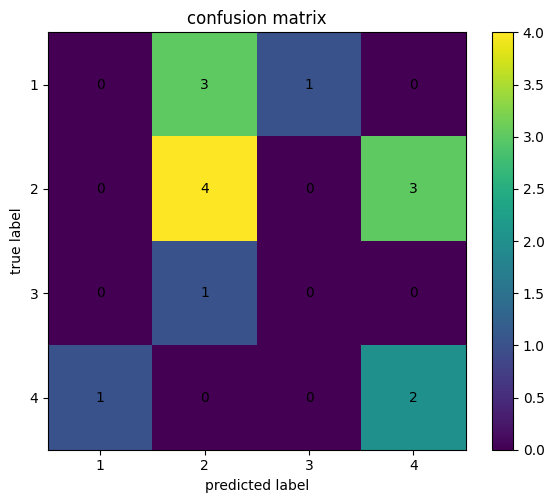

In [75]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("confusion matrix")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.colorbar()

plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

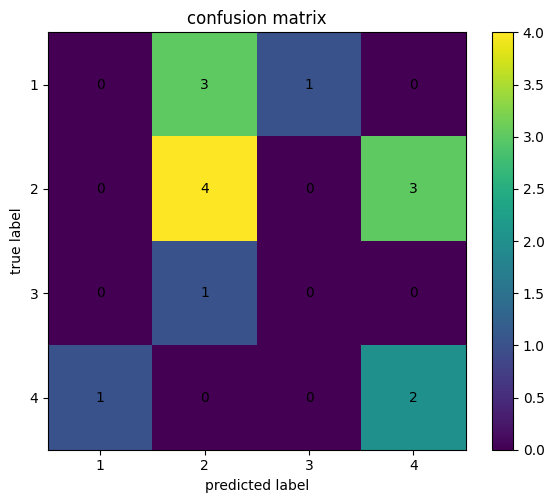

confusion matrix saved at:
/content/assignment_3_outputs/plots/confusion_matrix.png


In [76]:
# save confusion matrix image

cm_file = os.path.join(plot_path, "confusion_matrix.png")

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("confusion matrix")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.colorbar()

plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(cm_file, dpi=300)
plt.show()

print("confusion matrix saved at:")
print(cm_file)

feature importance

In [77]:
# show feature importance from random forest model

importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(by="importance", ascending=False)

importance_csv = os.path.join(feature_path, "feature_importance.csv")
importance_df.to_csv(importance_csv, index=False)

importance_df

,feature,importance
7,circularity,0.153491
6,perimeter,0.147386
3,area,0.144299
2,contrast,0.136507
5,centroid_y,0.109198
1,entropy,0.109120
0,energy,0.101312
4,centroid_x,0.098687


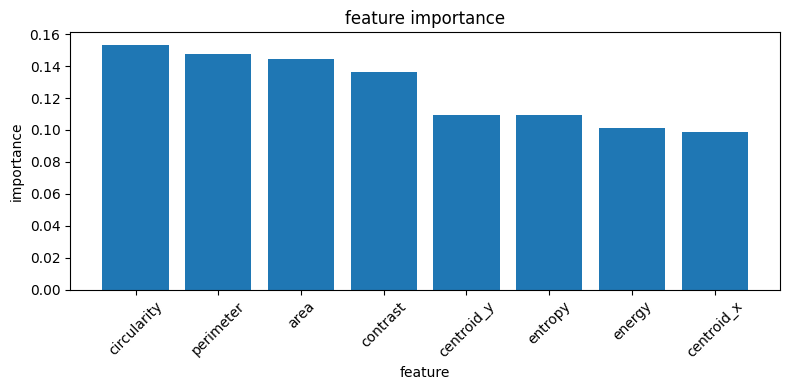

In [78]:
# plot feature importance

plt.figure(figsize=(8, 4))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.title("feature importance")
plt.xlabel("feature")
plt.ylabel("importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

save final outputs

In [ ]:
print("assignment 3 output folder:")
print(assignment_3_path)

print("\nfolders inside assignment 3 output:")
for item in os.listdir(assignment_3_path):
    print("-", item)

print("\nfeature vector files:")
for item in os.listdir(feature_path):
    print("-", item)

print("\nclassification report files:")
for item in os.listdir(report_path):
    print("-", item)

print("\nplot files:")
for item in os.listdir(plot_path):
    print("-", item)

In [79]:
# create zip file for assignment 3 outputs

!zip -r /content/assignment_3_outputs.zip /content/assignment_3_outputs > /dev/null

print("zip file created:")
print("/content/assignment_3_outputs.zip")

zip file created:
/content/assignment_3_outputs.zip


# **DEEP LEARNING PIPELINE**

In [80]:
# create final project output folders

final_project_path = "/content/final_project_outputs"

annotated_dataset_path = os.path.join(final_project_path, "final_annotated_dataset")
image_path = os.path.join(annotated_dataset_path, "images")
mask_path = os.path.join(annotated_dataset_path, "masks")
overlay_path = os.path.join(annotated_dataset_path, "overlays")

classification_dataset_path = os.path.join(final_project_path, "classification_dataset")
split_dataset_path = os.path.join(final_project_path, "train_test_dataset")

report_path = os.path.join(final_project_path, "evaluation_report")
plot_path = os.path.join(final_project_path, "plots")

for path in [image_path, mask_path, overlay_path, classification_dataset_path, split_dataset_path, report_path, plot_path]:
    os.makedirs(path, exist_ok=True)

print("final project folders created:")
print(final_project_path)

final project folders created:
/content/final_project_outputs


In [81]:
# define helper functions for loading and normalizing mri data

def load_mri(file_path):
    img = nib.load(file_path)
    data = img.get_fdata()
    return data


def normalize_to_uint8(slice_2d):
    slice_2d = slice_2d.astype(np.float32)

    min_value = np.min(slice_2d)
    max_value = np.max(slice_2d)

    if max_value - min_value == 0:
        return np.zeros_like(slice_2d, dtype=np.uint8)

    normalized = (slice_2d - min_value) / (max_value - min_value)
    uint8_img = (normalized * 255).astype(np.uint8)

    return uint8_img

In [82]:
# find mri modality file and segmentation file

def find_file(patient_folder, keyword):
    files = sorted(glob.glob(os.path.join(patient_folder, "*.nii.gz")))

    for file in files:
        name = os.path.basename(file).lower()
        if name.endswith("-" + keyword + ".nii.gz"):
            return file

    return None


def get_best_modality_file(patient_folder):
    preferred_modalities = ["t2f", "t2w", "t1c", "t1n"]

    for modality in preferred_modalities:
        file_path = find_file(patient_folder, modality)
        if file_path is not None:
            return file_path, modality

    return None, None


def get_seg_file(patient_folder):
    return find_file(patient_folder, "seg")

In [83]:
# create tumor mask overlay on original mri slice

def create_overlay(img_uint8, mask_uint8):
    img_color = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)

    red_mask = np.zeros_like(img_color)
    red_mask[:, :, 2] = mask_uint8

    overlay = cv2.addWeighted(img_color, 0.75, red_mask, 0.25, 0)

    return overlay

## **part 1: acquisition, preprocessing, segmentation, and annotation**

In [84]:
# create final annotated dataset from brats-ped mri volumes

metadata_records = []

max_patients = None
max_tumor_slices_per_patient = 10
max_normal_slices_per_patient = 10

selected_folders = patient_folders

if max_patients is not None:
    selected_folders = patient_folders[:max_patients]

for patient_folder in selected_folders:
    patient_id = os.path.basename(patient_folder)
    print("processing:", patient_id)

    modality_file, modality_name = get_best_modality_file(patient_folder)
    seg_file = get_seg_file(patient_folder)

    if modality_file is None or seg_file is None:
        print("missing modality or segmentation file:", patient_id)
        continue

    try:
        mri_volume = load_mri(modality_file)
        seg_volume = load_mri(seg_file)

        tumor_counts = []
        brain_counts = []

        for i in range(seg_volume.shape[2]):
            tumor_counts.append(np.count_nonzero(seg_volume[:, :, i]))
            brain_counts.append(np.count_nonzero(mri_volume[:, :, i]))

        tumor_counts = np.array(tumor_counts)
        brain_counts = np.array(brain_counts)

        tumor_slices = np.where(tumor_counts > 50)[0]
        normal_slices = np.where((tumor_counts == 0) & (brain_counts > 1000))[0]

        tumor_slices = tumor_slices[np.argsort(tumor_counts[tumor_slices])[::-1]]

        if len(tumor_slices) > max_tumor_slices_per_patient:
            tumor_slices = tumor_slices[:max_tumor_slices_per_patient]

        if len(normal_slices) > max_normal_slices_per_patient:
            normal_slices = np.linspace(
                normal_slices[0],
                normal_slices[-1],
                max_normal_slices_per_patient
            ).astype(int)

        selected_slices = []

        for slice_index in tumor_slices:
            selected_slices.append((slice_index, "tumor"))

        for slice_index in normal_slices:
            selected_slices.append((slice_index, "no_tumor"))

        for slice_index, label in selected_slices:
            mri_slice = mri_volume[:, :, slice_index]
            seg_slice = seg_volume[:, :, slice_index]

            img_uint8 = normalize_to_uint8(mri_slice)

            # preprocessing from assignment 1
            img_uint8 = cv2.medianBlur(img_uint8, 5)

            mask_uint8 = (seg_slice > 0).astype(np.uint8) * 255

            file_base = patient_id + "_slice_" + str(slice_index) + "_" + label

            img_file = os.path.join(image_path, file_base + ".png")
            mask_file = os.path.join(mask_path, file_base + "_mask.png")
            overlay_file = os.path.join(overlay_path, file_base + "_overlay.png")

            cv2.imwrite(img_file, img_uint8)
            cv2.imwrite(mask_file, mask_uint8)

            overlay = create_overlay(img_uint8, mask_uint8)
            cv2.imwrite(overlay_file, overlay)

            label_folder = os.path.join(classification_dataset_path, label)
            os.makedirs(label_folder, exist_ok=True)

            class_img_file = os.path.join(label_folder, file_base + ".png")
            cv2.imwrite(class_img_file, img_uint8)

            metadata_records.append({
                "patient_id": patient_id,
                "modality_used": modality_name,
                "slice_index": int(slice_index),
                "label": label,
                "tumor_pixels": int(np.count_nonzero(mask_uint8)),
                "image_path": img_file,
                "mask_path": mask_file,
                "overlay_path": overlay_file,
                "classification_image_path": class_img_file
            })

    except Exception as e:
        print("error processing:", patient_id)
        print(e)

metadata_df = pd.DataFrame(metadata_records)

metadata_csv = os.path.join(final_project_path, "final_annotated_dataset_metadata.csv")
metadata_df.to_csv(metadata_csv, index=False)

print("final annotated dataset created")
print("metadata saved at:")
print(metadata_csv)

print("\nlabel counts:")
print(metadata_df["label"].value_counts())

metadata_df.head()

processing: BraTS-PED-00128-000
processing: BraTS-PED-00129-000
processing: BraTS-PED-00130-000
error processing: BraTS-PED-00130-000
Error -3 while decompressing data: too many length or distance symbols
processing: BraTS-PED-00131-000
processing: BraTS-PED-00132-000
processing: BraTS-PED-00133-000
processing: BraTS-PED-00134-000
processing: BraTS-PED-00135-000
processing: BraTS-PED-00136-000
processing: BraTS-PED-00137-000
processing: BraTS-PED-00138-000
processing: BraTS-PED-00139-000
processing: BraTS-PED-00140-000
processing: BraTS-PED-00141-000
processing: BraTS-PED-00142-000
processing: BraTS-PED-00143-000
processing: BraTS-PED-00144-000
processing: BraTS-PED-00145-000
processing: BraTS-PED-00146-000
processing: BraTS-PED-00147-000
processing: BraTS-PED-00148-000
processing: BraTS-PED-00149-000
processing: BraTS-PED-00150-000
processing: BraTS-PED-00151-000
processing: BraTS-PED-00152-000
final annotated dataset created
metadata saved at:
/content/final_project_outputs/final_ann

,patient_id,modality_used,slice_index,label,tumor_pixels,image_path,mask_path,overlay_path,classification_image_path
0,BraTS-PED-00128-000,t2f,123,tumor,816,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/classification_...
1,BraTS-PED-00128-000,t2f,127,tumor,813,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/classification_...
2,BraTS-PED-00128-000,t2f,125,tumor,812,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/classification_...
3,BraTS-PED-00128-000,t2f,122,tumor,812,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/classification_...
4,BraTS-PED-00128-000,t2f,124,tumor,810,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/final_annotated...,/content/final_project_outputs/classification_...


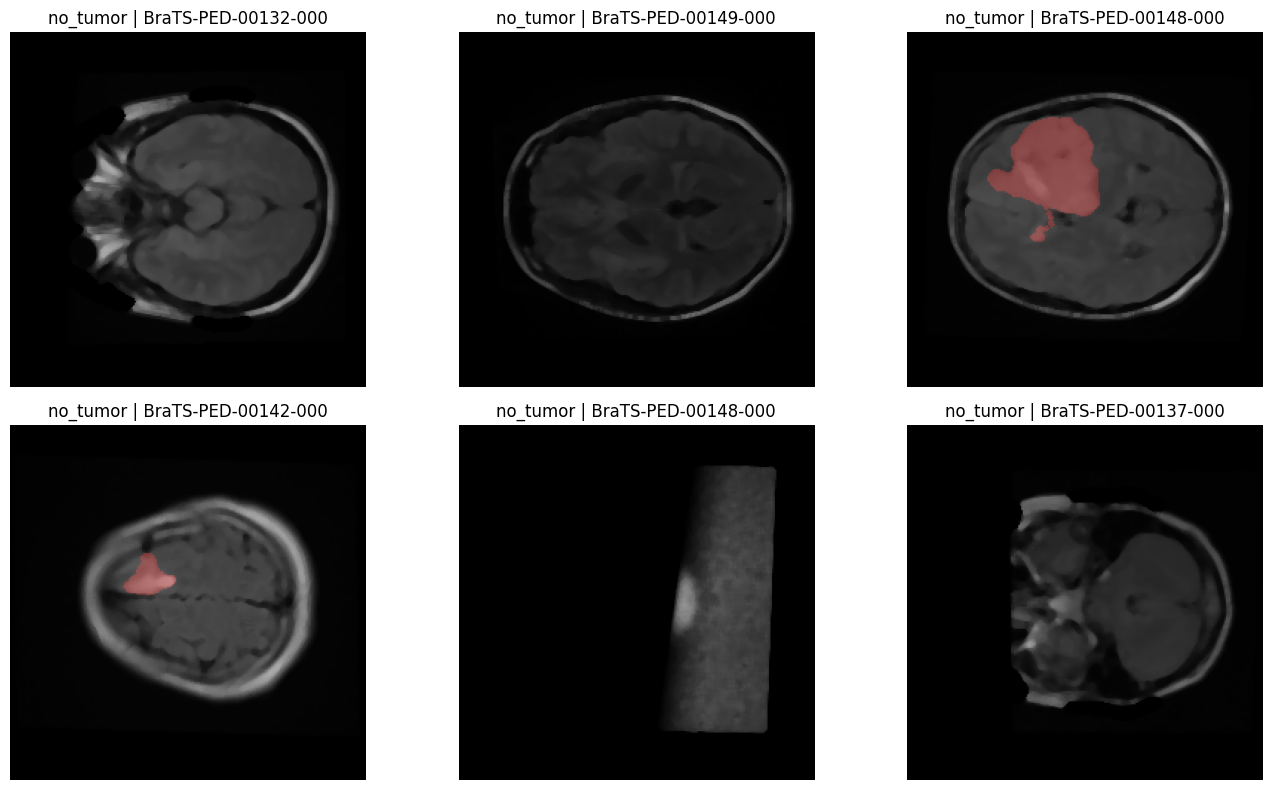

In [85]:
# view sample images from final annotated dataset

sample_rows = metadata_df.sample(min(6, len(metadata_df)), random_state=42)

plt.figure(figsize=(14, 8))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = cv2.imread(row["overlay_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(row["label"] + " | " + row["patient_id"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [86]:
# split data into train and test sets using patient ids

unique_patients = metadata_df["patient_id"].unique()

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.25,
    random_state=42
)

print("training patients:", len(train_patients))
print("testing patients:", len(test_patients))

training patients: 18
testing patients: 6


In [87]:
# split data into train and test sets using patient ids

unique_patients = metadata_df["patient_id"].unique()

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.25,
    random_state=42
)

print("training patients:", len(train_patients))
print("testing patients:", len(test_patients))

training patients: 18
testing patients: 6


In [89]:
import shutil

# create train and test folders for cnn classification

for split_name in ["train", "test"]:
    for label in ["tumor", "no_tumor"]:
        os.makedirs(os.path.join(split_dataset_path, split_name, label), exist_ok=True)

for _, row in metadata_df.iterrows():
    patient_id = row["patient_id"]
    label = row["label"]
    src_path = row["classification_image_path"]

    if patient_id in train_patients:
        split_name = "train"
    else:
        split_name = "test"

    dst_path = os.path.join(
        split_dataset_path,
        split_name,
        label,
        os.path.basename(src_path)
    )

    shutil.copy(src_path, dst_path)

print("train-test dataset created at:")
print(split_dataset_path)

for split_name in ["train", "test"]:
    print("\n", split_name)
    for label in ["tumor", "no_tumor"]:
        folder = os.path.join(split_dataset_path, split_name, label)
        print(label, ":", len(os.listdir(folder)))

train-test dataset created at:
/content/final_project_outputs/train_test_dataset

 train
tumor : 180
no_tumor : 180

 test
tumor : 60
no_tumor : 60


In [91]:
# load train and test dataset for cnn model
import tensorflow as tf
img_size = (128, 128)
batch_size = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dataset_path, "train"),
    image_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    label_mode="binary",
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dataset_path, "test"),
    image_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names

print("class names:", class_names)

Found 360 files belonging to 2 classes.
Found 120 files belonging to 2 classes.
class names: ['no_tumor', 'tumor']


In [93]:
# normalize image pixel values for cnn training

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [98]:
# add data augmentation and early stopping to reduce overfitting

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [99]:
# build simple cnn model for tumor classification
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score
# build smaller cnn model to reduce overfitting

model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),

    data_augmentation,

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,521 (107.50 KB)

 Trainable params: 27,521 (107.50 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
# train cnn model

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 323ms/step - accuracy: 0.6389 - loss: 0.6421 - precision: 0.6202 - recall: 0.7167 - val_accuracy: 0.5167 - val_loss: 0.6669 - val_precision: 0.5294 - val_recall: 0.3000
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 341ms/step - accuracy: 0.6250 - loss: 0.6378 - precision: 0.6098 - recall: 0.6944 - val_accuracy: 0.6167 - val_loss: 0.6575 - val_precision: 0.5814 - val_recall: 0.8333
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step - accuracy: 0.6194 - loss: 0.6463 - precision: 0.6000 - recall: 0.7167 - val_accuracy: 0.5833 - val_loss: 0.6547 - val_precision: 0.5735 - val_recall: 0.6500
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 278ms/step - accuracy: 0.6528 - loss: 0.6138 - precision: 0.6503 - recall: 0.6611 - val_accuracy: 0.6500 - val_loss: 0.6547 - val_precision: 0.6000 - val_recall: 0.9000
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 412ms/step - accuracy: 0.6556 - loss: 0.6131 - precision: 0.6429 - recall: 0.7000 - val_accuracy: 0.6000 - val_loss: 0

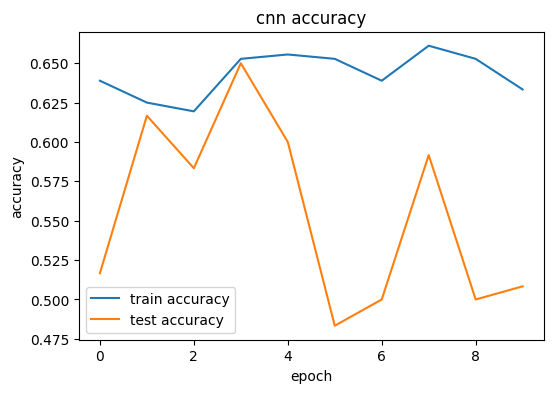

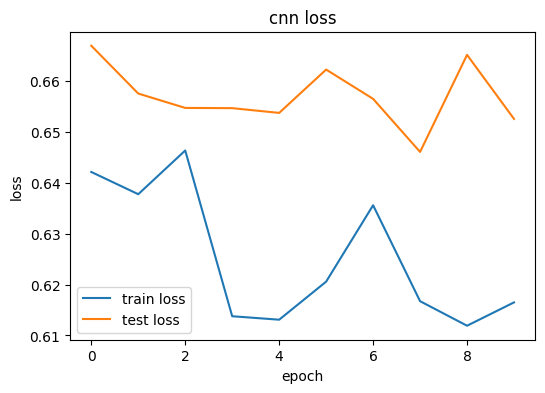

In [102]:
# plot cnn training accuracy and loss

plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="test accuracy")
plt.title("cnn accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="test loss")
plt.title("cnn loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

evaluation

In [103]:
# get cnn predictions on test data

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    predictions = model.predict(images)

    for label, pred in zip(labels.numpy(), predictions):
        y_true.append(int(label[0]))
        y_prob.append(float(pred[0]))
        y_pred.append(1 if pred[0] >= 0.5 else 0)

print("total test samples:", len(y_true))
print("accuracy:", accuracy_score(y_true, y_pred))
print("precision:", precision_score(y_true, y_pred))
print("recall:", recall_score(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
total test samples: 120
accuracy: 0.5083333333333333
precision: 0.5102040816326531
recall: 0.4166666666666667


In [104]:
# create classification report with precision and recall

final_accuracy = accuracy_score(y_true, y_pred)
final_precision = precision_score(y_true, y_pred)
final_recall = recall_score(y_true, y_pred)

class_report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("classification accuracy:", final_accuracy)
print("precision:", final_precision)
print("recall:", final_recall)

print("\nclassification report:\n")
print(class_report)

classification accuracy: 0.5083333333333333
precision: 0.5102040816326531
recall: 0.4166666666666667

classification report:

              precision    recall  f1-score   support

    no_tumor       0.51      0.60      0.55        60
       tumor       0.51      0.42      0.46        60

    accuracy                           0.51       120
   macro avg       0.51      0.51      0.50       120
weighted avg       0.51      0.51      0.50       120



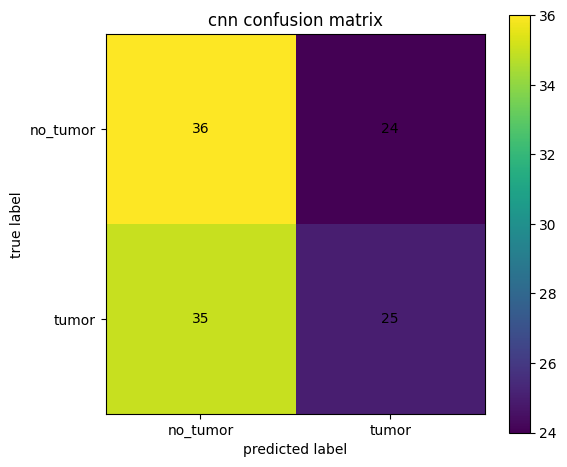

In [105]:
# create and display confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("cnn confusion matrix")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [106]:
# save cnn model and evaluation report

model_file = os.path.join(final_project_path, "cnn_tumor_classifier.h5")
model.save(model_file)

report_file = os.path.join(report_path, "final_project_classification_report.txt")

with open(report_file, "w") as file:
    file.write("project: deep vision pipeline\n")
    file.write("============================================\n\n")
    file.write("dataset: brats-ped brain tumor mri dataset\n")
    file.write("model: cnn binary classifier\n")
    file.write("classes: no_tumor and tumor\n\n")
    file.write("pipeline: acquisition -> preprocessing -> segmentation -> description -> recognition\n\n")
    file.write("accuracy: " + str(final_accuracy) + "\n")
    file.write("precision: " + str(final_precision) + "\n")
    file.write("recall: " + str(final_recall) + "\n\n")
    file.write("classification report:\n")
    file.write(class_report)

print("model saved at:")
print(model_file)

print("\nreport saved at:")
print(report_file)

model saved at:
/content/final_project_outputs/cnn_tumor_classifier.h5

report saved at:
/content/final_project_outputs/evaluation_report/final_project_classification_report.txt


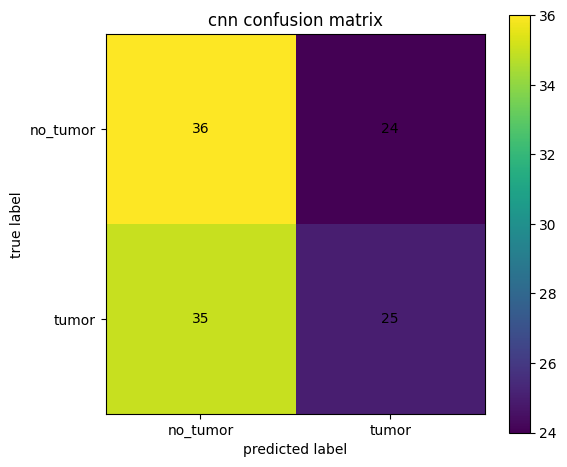

confusion matrix saved at:
/content/final_project_outputs/plots/cnn_confusion_matrix.png


In [107]:
# save confusion matrix image

cm_file = os.path.join(plot_path, "cnn_confusion_matrix.png")

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("cnn confusion matrix")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(cm_file, dpi=300)
plt.show()

print("confusion matrix saved at:")
print(cm_file)

## **optional bonus: simple transformer attention model**

In [108]:
# build cnn model with a simple transformer attention block

input_layer = layers.Input(shape=(128, 128, 1))

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_layer)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2))(x)

shape = x.shape
x = layers.Reshape((shape[1] * shape[2], shape[3]))(x)

attention_output = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(x, x)

x = layers.Add()([x, attention_output])
x = layers.LayerNormalization()(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

output_layer = layers.Dense(1, activation="sigmoid")(x)

transformer_model = models.Model(input_layer, output_layer)

transformer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

transformer_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 16, 16,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 256, 128)  │          0 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 128)  │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │        129 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 175,617 (686.00 KB)

 Trainable params: 175,617 (686.00 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
# train transformer attention model

transformer_history = transformer_model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5694 - loss: 0.7051 - precision: 0.5598 - recall: 0.6500 - val_accuracy: 0.5000 - val_loss: 0.8306 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 986ms/step - accuracy: 0.5111 - loss: 0.7235 - precision: 0.5132 - recall: 0.4333 - val_accuracy: 0.6000 - val_loss: 0.6710 - val_precision: 0.5811 - val_recall: 0.7167
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5500 - loss: 0.6716 - precision: 0.5455 - recall: 0.6000 - val_accuracy: 0.5333 - val_loss: 0.6627 - val_precision: 0.5400 - val_recall: 0.4500
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 977ms/step - accuracy: 0.6333 - loss: 0.6242 - precision: 0.6188 - recall: 0.6944 - val_accuracy: 0.5750 - val_loss: 0.6997 - val_precision: 0.5405 - val_recall: 1.0000
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6583 - loss: 0.6091 - precision: 0.6326 - recall: 0.7556 - val_accuracy: 0.4750 - val_loss

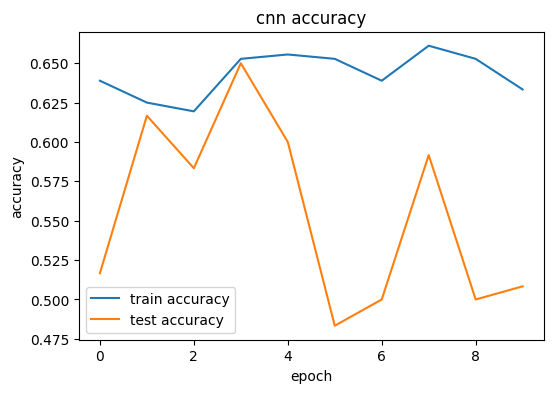

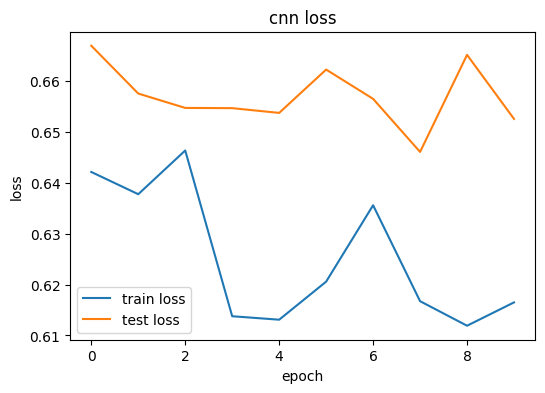

In [110]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="test accuracy")
plt.title("cnn accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="test loss")
plt.title("cnn loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [111]:
# check final project output folders

print("final project output folder:")
print(final_project_path)

print("\nfolders/files inside final project folder:")
for item in os.listdir(final_project_path):
    print("-", item)

final project output folder:
/content/final_project_outputs

folders/files inside final project folder:
- evaluation_report
- final_annotated_dataset
- cnn_tumor_classifier.h5
- classification_dataset
- final_annotated_dataset_metadata.csv
- plots
- train_test_dataset


In [113]:
# check final project output folders

print("final project output folder:")
print(final_project_path)

print("\nfolders/files inside final project folder:")
for item in os.listdir(final_project_path):
    print("-", item)

final project output folder:
/content/final_project_outputs

folders/files inside final project folder:
- evaluation_report
- final_annotated_dataset
- cnn_tumor_classifier.h5
- classification_dataset
- final_annotated_dataset_metadata.csv
- plots
- train_test_dataset


In [114]:
# create zip file for final project outputs

!zip -r /content/final_project_outputs.zip /content/final_project_outputs > /dev/null

print("zip file created:")
print("/content/final_project_outputs.zip")

zip file created:
/content/final_project_outputs.zip
